Notebook purpose

**Fake News Detection - Exploratory Data Analysis Notebook**
**Goal: Analyze cleaned dataset using class distribution, language distribution, text length, word frequency, and word clouds.**

In [1]:
from pathlib import Path

def find_project_root(start_path: Path) -> Path:
    """
    Find project root folder by checking for requirements.txt and data folder.
    """
    start_path = start_path.resolve()

    for path in [start_path] + list(start_path.parents):
        if (path / "requirements.txt").exists() and (path / "data").exists():
            return path

    return start_path


PROJECT_ROOT = find_project_root(Path.cwd())

CLEANED_DATA_PATH = PROJECT_ROOT / "data" / "processed" / "cleaned_news.csv"

REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"
METRICS_DIR = REPORTS_DIR / "metrics"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
METRICS_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Cleaned data path:", CLEANED_DATA_PATH)
print("Figures folder:", FIGURES_DIR)
print("Metrics folder:", METRICS_DIR)

Project root: /home/kinkini/Documents/NLP Dont delte/fake news detector/NLP_Group_05
Cleaned data path: /home/kinkini/Documents/NLP Dont delte/fake news detector/NLP_Group_05/data/processed/cleaned_news.csv
Figures folder: /home/kinkini/Documents/NLP Dont delte/fake news detector/NLP_Group_05/reports/figures
Metrics folder: /home/kinkini/Documents/NLP Dont delte/fake news detector/NLP_Group_05/reports/metrics


Import pandas and load cleaned dataset

In [2]:
import pandas as pd

if not CLEANED_DATA_PATH.exists():
    raise FileNotFoundError(
        f"cleaned_news.csv not found at: {CLEANED_DATA_PATH}\n"
        "Please run 02_preprocessing.ipynb first."
    )

data = pd.read_csv(CLEANED_DATA_PATH)

print("Cleaned dataset loaded successfully.")
print("Dataset shape:", data.shape)

print("\nColumns:")
print(data.columns.tolist())

display(data.head())

Cleaned dataset loaded successfully.
Dataset shape: (39098, 5)

Columns:
['content', 'detected_language', 'english_content', 'clean_text', 'label']


,content,detected_language,english_content,clean_text,label
0,Donald Trump Sends Out Embarrassing New Year’s...,English,Donald Trump Sends Out Embarrassing New Year’s...,donald trump sends embarrassing new year eve m...,0
1,Drunk Bragging Trump Staffer Started Russian C...,English,Drunk Bragging Trump Staffer Started Russian C...,drunk bragging trump staffer started russian c...,0
2,Sheriff David Clarke Becomes An Internet Joke ...,English,Sheriff David Clarke Becomes An Internet Joke ...,sheriff david clarke becomes internet joke thr...,0
3,Trump Is So Obsessed He Even Has Obama’s Name ...,English,Trump Is So Obsessed He Even Has Obama’s Name ...,trump obsessed even obama name coded website i...,0
4,Pope Francis Just Called Out Donald Trump Duri...,English,Pope Francis Just Called Out Donald Trump Duri...,pope francis called donald trump christmas spe...,0


Basic dataset information

In [3]:
print("Dataset Information")
print("-------------------")

print("Total records:", len(data))

print("\nMissing values:")
print(data.isnull().sum())

print("\nClass distribution:")
print(data["label"].value_counts())

print("\nClass distribution percentage:")
print(data["label"].value_counts(normalize=True) * 100)

if "detected_language" in data.columns:
    print("\nLanguage distribution:")
    print(data["detected_language"].value_counts())

Dataset Information
-------------------
Total records: 39098

Missing values:
content              0
detected_language    0
english_content      0
clean_text           0
label                0
dtype: int64

Class distribution:
label
1    21196
0    17902
Name: count, dtype: int64

Class distribution percentage:
label
1    54.212492
0    45.787508
Name: proportion, dtype: float64

Language distribution:
detected_language
English    39098
Name: count, dtype: int64


Add label names

In [4]:
label_mapping = {
    0: "Fake News",
    1: "Real News"
}

data["label_name"] = data["label"].map(label_mapping)

display(data[["clean_text", "label", "label_name"]].head())

,clean_text,label,label_name
0,donald trump sends embarrassing new year eve m...,0,Fake News
1,drunk bragging trump staffer started russian c...,0,Fake News
2,sheriff david clarke becomes internet joke thr...,0,Fake News
3,trump obsessed even obama name coded website i...,0,Fake News
4,pope francis called donald trump christmas spe...,0,Fake News


Class distribution graph

Matplotlib is building the font cache; this may take a moment.


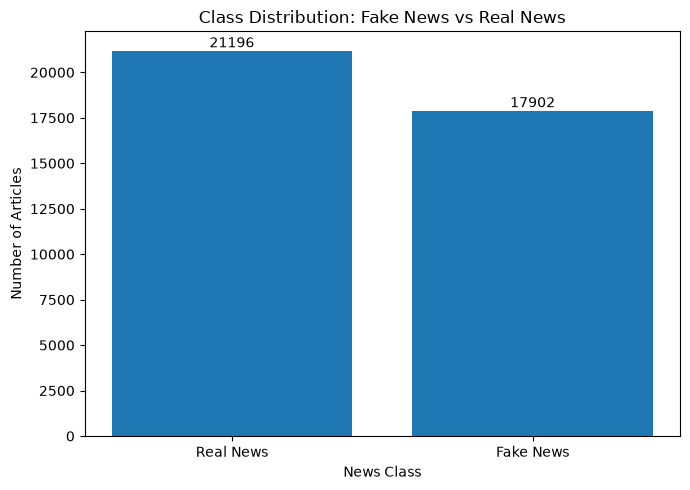

Class distribution graph saved to: /home/kinkini/Documents/NLP Dont delte/fake news detector/NLP_Group_05/reports/figures/class_distribution.png


In [6]:
import matplotlib.pyplot as plt

class_counts = data["label_name"].value_counts()

plt.figure(figsize=(7, 5))
plt.bar(class_counts.index, class_counts.values)

plt.title("Class Distribution: Fake News vs Real News")
plt.xlabel("News Class")
plt.ylabel("Number of Articles")

for index, value in enumerate(class_counts.values):
    plt.text(index, value, str(value), ha="center", va="bottom")

plt.tight_layout()

class_distribution_path = FIGURES_DIR / "class_distribution.png"
plt.savefig(class_distribution_path)
plt.show()

print("Class distribution graph saved to:", class_distribution_path)

Language distribution graph

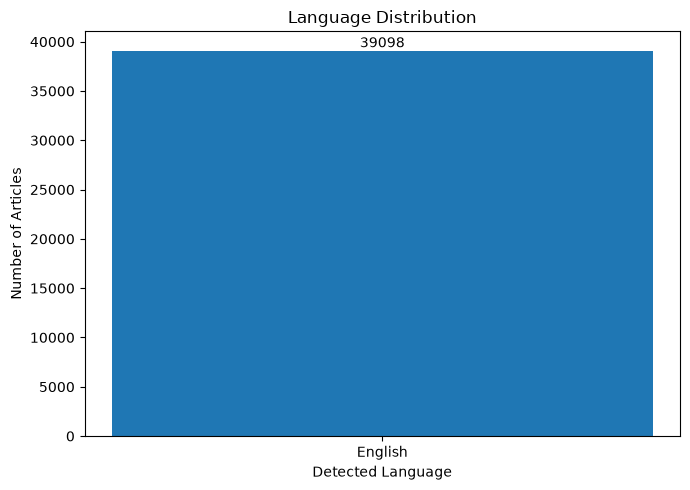

Language distribution graph saved to: /home/kinkini/Documents/NLP Dont delte/fake news detector/NLP_Group_05/reports/figures/language_distribution.png


In [7]:
if "detected_language" in data.columns:
    language_counts = data["detected_language"].value_counts()

    plt.figure(figsize=(7, 5))
    plt.bar(language_counts.index, language_counts.values)

    plt.title("Language Distribution")
    plt.xlabel("Detected Language")
    plt.ylabel("Number of Articles")

    for index, value in enumerate(language_counts.values):
        plt.text(index, value, str(value), ha="center", va="bottom")

    plt.tight_layout()

    language_distribution_path = FIGURES_DIR / "language_distribution.png"
    plt.savefig(language_distribution_path)
    plt.show()

    print("Language distribution graph saved to:", language_distribution_path)
else:
    print("detected_language column not found. Skipping language distribution graph.")

Text length analysis

In [8]:
data["clean_text"] = data["clean_text"].fillna("").astype(str)

data["word_count"] = data["clean_text"].apply(lambda text: len(text.split()))
data["char_count"] = data["clean_text"].apply(len)

display(data[["clean_text", "word_count", "char_count", "label_name"]].head())

print("Word count statistics by class:")
display(data.groupby("label_name")["word_count"].describe())

print("Character count statistics by class:")
display(data.groupby("label_name")["char_count"].describe())

,clean_text,word_count,char_count,label_name
0,donald trump sends embarrassing new year eve m...,273,1852,Fake News
1,drunk bragging trump staffer started russian c...,185,1410,Fake News
2,sheriff david clarke becomes internet joke thr...,346,2404,Fake News
3,trump obsessed even obama name coded website i...,263,1819,Fake News
4,pope francis called donald trump christmas spe...,215,1464,Fake News


Word count statistics by class:


,count,mean,std,min,25%,50%,75%,max
label_name,,,,,,,,
Fake News,17902.0,236.937214,201.062288,3.0,155.0,212.0,281.75,4910.0
Real News,21196.0,232.670598,158.130625,4.0,94.0,217.0,312.00,2342.0


Character count statistics by class:


,count,mean,std,min,25%,50%,75%,max
label_name,,,,,,,,
Fake News,17902.0,1709.059602,1505.157192,22.0,1100.0,1512.0,2026.0,37915.0
Real News,21196.0,1725.548924,1169.465873,29.0,695.0,1607.5,2317.0,17514.0


Word count distribution graph

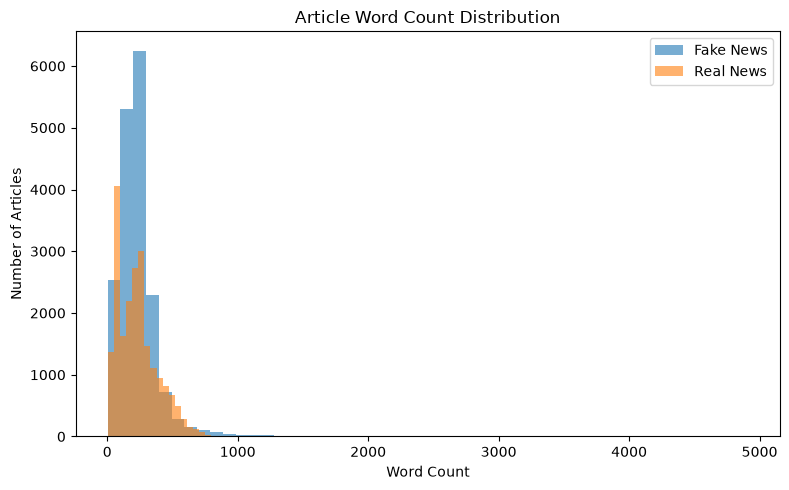

Word count distribution graph saved to: /home/kinkini/Documents/NLP Dont delte/fake news detector/NLP_Group_05/reports/figures/word_count_distribution.png


In [9]:
fake_word_counts = data[data["label"] == 0]["word_count"]
real_word_counts = data[data["label"] == 1]["word_count"]

plt.figure(figsize=(8, 5))

plt.hist(fake_word_counts, bins=50, alpha=0.6, label="Fake News")
plt.hist(real_word_counts, bins=50, alpha=0.6, label="Real News")

plt.title("Article Word Count Distribution")
plt.xlabel("Word Count")
plt.ylabel("Number of Articles")
plt.legend()

plt.tight_layout()

word_count_distribution_path = FIGURES_DIR / "word_count_distribution.png"
plt.savefig(word_count_distribution_path)
plt.show()

print("Word count distribution graph saved to:", word_count_distribution_path)

Import Counter for word frequency

In [10]:
from collections import Counter

def get_top_words(text_series, top_n=20):
    """
    Get top N frequent words from a text column.
    """
    all_words = " ".join(text_series.fillna("").astype(str)).split()
    word_counts = Counter(all_words)

    return word_counts.most_common(top_n)

print("Counter imported for word frequency analysis.")

Counter imported for word frequency analysis.


Top words in Fake News

In [11]:
fake_text = data[data["label"] == 0]["clean_text"]

top_fake_words = get_top_words(fake_text, top_n=20)

fake_words_df = pd.DataFrame(
    top_fake_words,
    columns=["word", "count"]
)

display(fake_words_df)

,word,count
0,trump,76575
1,said,24958
2,president,22170
3,people,21674
4,one,20081
5,would,18457
6,state,17497
7,donald,16145
8,republican,15483
9,like,15167


Fake News top words graph

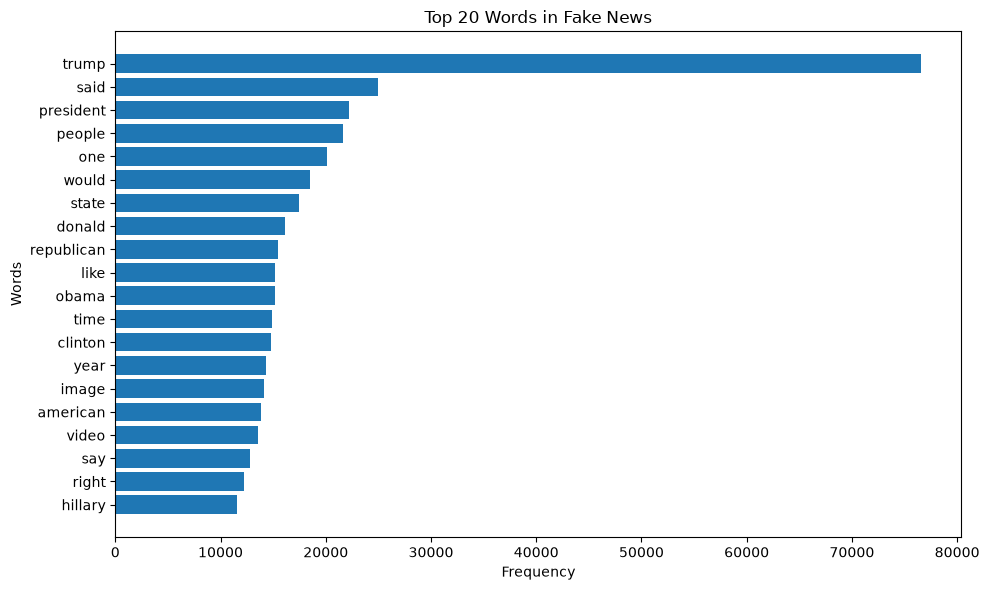

Top fake words graph saved to: /home/kinkini/Documents/NLP Dont delte/fake news detector/NLP_Group_05/reports/figures/top_words_fake_news.png


In [12]:
plt.figure(figsize=(10, 6))

plt.barh(fake_words_df["word"], fake_words_df["count"])

plt.title("Top 20 Words in Fake News")
plt.xlabel("Frequency")
plt.ylabel("Words")
plt.gca().invert_yaxis()

plt.tight_layout()

top_fake_words_path = FIGURES_DIR / "top_words_fake_news.png"
plt.savefig(top_fake_words_path)
plt.show()

print("Top fake words graph saved to:", top_fake_words_path)

Top words in Real News

In [13]:
real_text = data[data["label"] == 1]["clean_text"]

top_real_words = get_top_words(real_text, top_n=20)

real_words_df = pd.DataFrame(
    top_real_words,
    columns=["word", "count"]
)

display(real_words_df)

,word,count
0,said,97844
1,trump,59618
2,state,38034
3,would,31471
4,president,28919
5,reuters,28781
6,republican,23826
7,year,22599
8,government,20096
9,house,18316


Real News top words graph

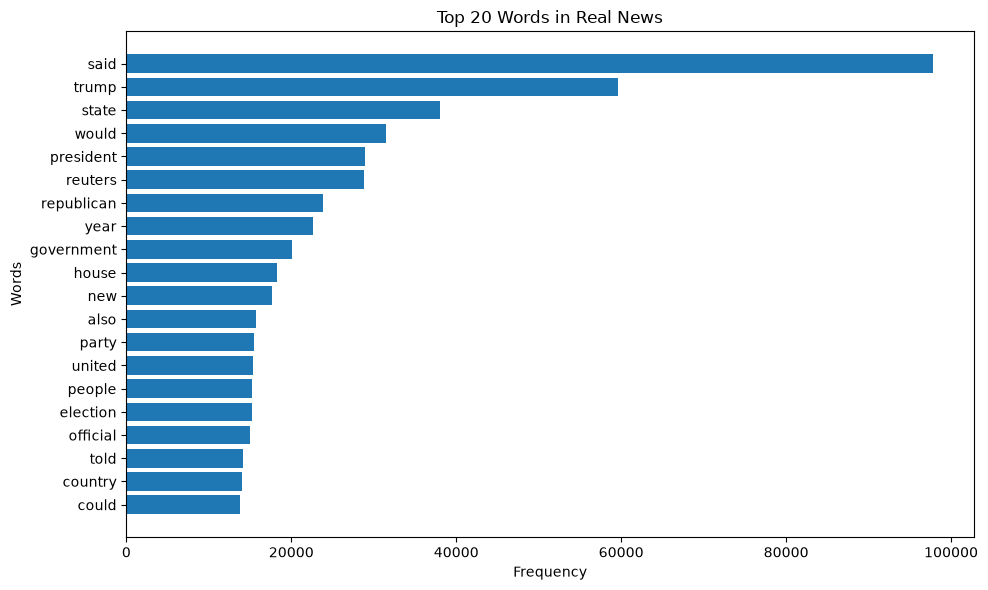

Top real words graph saved to: /home/kinkini/Documents/NLP Dont delte/fake news detector/NLP_Group_05/reports/figures/top_words_real_news.png


In [14]:
plt.figure(figsize=(10, 6))

plt.barh(real_words_df["word"], real_words_df["count"])

plt.title("Top 20 Words in Real News")
plt.xlabel("Frequency")
plt.ylabel("Words")
plt.gca().invert_yaxis()

plt.tight_layout()

top_real_words_path = FIGURES_DIR / "top_words_real_news.png"
plt.savefig(top_real_words_path)
plt.show()

print("Top real words graph saved to:", top_real_words_path)

Import WordCloud

In [16]:
from wordcloud import WordCloud

print("WordCloud imported for visual word-frequency representation.")

WordCloud imported for visual word-frequency representation.


Fake News word cloud

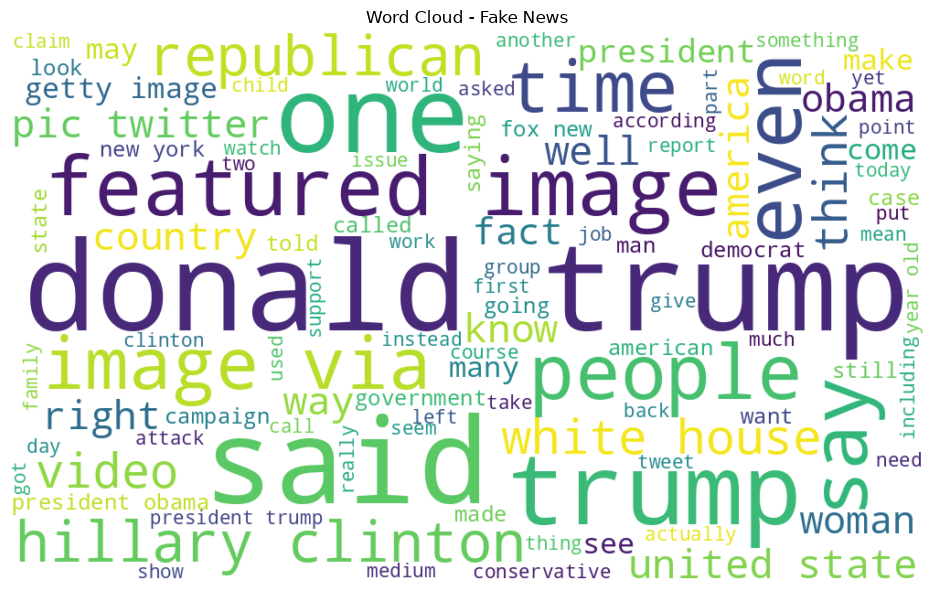

Fake news word cloud saved to: /home/kinkini/Documents/NLP Dont delte/fake news detector/NLP_Group_05/reports/figures/fake_news_wordcloud.png


In [17]:
fake_text_combined = " ".join(fake_text.fillna("").astype(str))

if fake_text_combined.strip():
    fake_wordcloud = WordCloud(
        width=1000,
        height=600,
        background_color="white",
        max_words=100
    ).generate(fake_text_combined)

    plt.figure(figsize=(10, 6))
    plt.imshow(fake_wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title("Word Cloud - Fake News")
    plt.tight_layout()

    fake_wordcloud_path = FIGURES_DIR / "fake_news_wordcloud.png"
    plt.savefig(fake_wordcloud_path)
    plt.show()

    print("Fake news word cloud saved to:", fake_wordcloud_path)
else:
    print("No fake news text available for word cloud.")

Real News word cloud

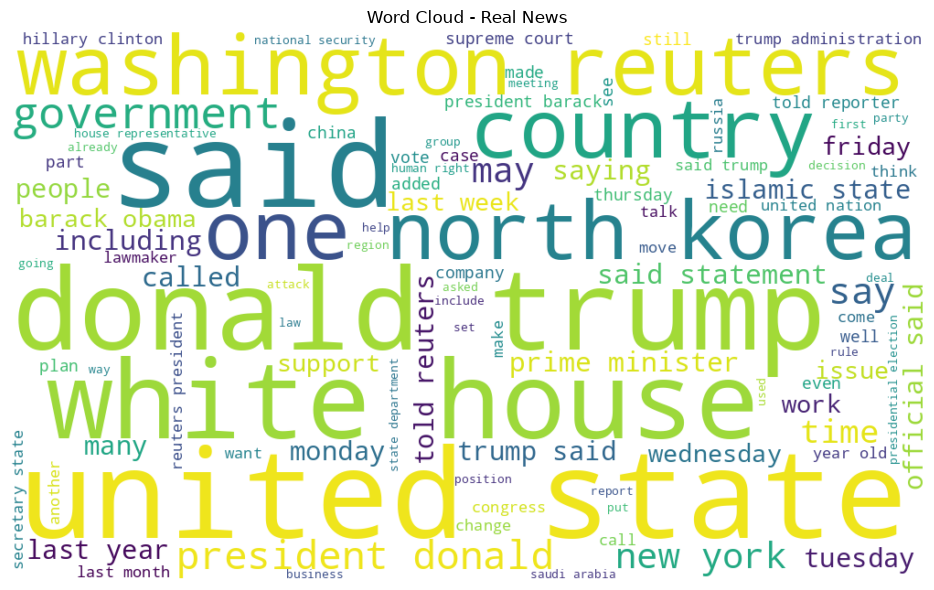

Real news word cloud saved to: /home/kinkini/Documents/NLP Dont delte/fake news detector/NLP_Group_05/reports/figures/real_news_wordcloud.png


In [18]:
real_text_combined = " ".join(real_text.fillna("").astype(str))

if real_text_combined.strip():
    real_wordcloud = WordCloud(
        width=1000,
        height=600,
        background_color="white",
        max_words=100
    ).generate(real_text_combined)

    plt.figure(figsize=(10, 6))
    plt.imshow(real_wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title("Word Cloud - Real News")
    plt.tight_layout()

    real_wordcloud_path = FIGURES_DIR / "real_news_wordcloud.png"
    plt.savefig(real_wordcloud_path)
    plt.show()

    print("Real news word cloud saved to:", real_wordcloud_path)
else:
    print("No real news text available for word cloud.")

Source distribution analysis

In [19]:
if "source" in data.columns:
    print("Source distribution:")
    print(data["source"].value_counts())

    source_counts = data["source"].value_counts()

    plt.figure(figsize=(10, 5))
    plt.bar(source_counts.index, source_counts.values)

    plt.title("Dataset Source Distribution")
    plt.xlabel("Dataset Source")
    plt.ylabel("Number of Articles")
    plt.xticks(rotation=45, ha="right")

    plt.tight_layout()

    source_distribution_path = FIGURES_DIR / "source_distribution.png"
    plt.savefig(source_distribution_path)
    plt.show()

    print("Source distribution graph saved to:", source_distribution_path)
else:
    print("source column not found. Skipping source distribution analysis.")

source column not found. Skipping source distribution analysis.


Save EDA summary

In [20]:
summary = {
    "total_records": len(data),
    "fake_news_count": int((data["label"] == 0).sum()),
    "real_news_count": int((data["label"] == 1).sum()),
    "average_word_count": float(data["word_count"].mean()),
    "average_fake_word_count": float(data[data["label"] == 0]["word_count"].mean()),
    "average_real_word_count": float(data[data["label"] == 1]["word_count"].mean()),
    "average_char_count": float(data["char_count"].mean())
}

if "detected_language" in data.columns:
    summary["sinhala_records"] = int((data["detected_language"] == "Sinhala").sum())
    summary["english_records"] = int((data["detected_language"] == "English").sum())

summary_df = pd.DataFrame([summary])

eda_summary_path = METRICS_DIR / "eda_summary.csv"
summary_df.to_csv(eda_summary_path, index=False)

display(summary_df)

print("EDA summary saved to:", eda_summary_path)

,total_records,fake_news_count,real_news_count,average_word_count,average_fake_word_count,average_real_word_count,average_char_count,sinhala_records,english_records
0,39098,17902,21196,234.624175,236.937214,232.670598,1717.998875,0,39098


EDA summary saved to: /home/kinkini/Documents/NLP Dont delte/fake news detector/NLP_Group_05/reports/metrics/eda_summary.csv


Write EDA insights

In [21]:
print("EDA Insights")
print("------------")
print("1. Class distribution shows whether the dataset is balanced between Fake News and Real News.")
print("2. Language distribution shows whether the dataset contains English or Sinhala input records.")
print("3. Word count analysis helps compare article length between Fake and Real news.")
print("4. Word frequency analysis shows commonly occurring words in each class.")
print("5. Word clouds provide a visual summary of dominant words in Fake and Real news.")
print("6. Source distribution helps verify how much each dataset contributes after adding extra datasets.")

EDA Insights
------------
1. Class distribution shows whether the dataset is balanced between Fake News and Real News.
2. Language distribution shows whether the dataset contains English or Sinhala input records.
3. Word count analysis helps compare article length between Fake and Real news.
4. Word frequency analysis shows commonly occurring words in each class.
5. Word clouds provide a visual summary of dominant words in Fake and Real news.
6. Source distribution helps verify how much each dataset contributes after adding extra datasets.
